In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
# 1 : Load Dataset
df = pd.read_csv("C:\\Users\\shree\\OneDrive\\Desktop\\ESM Practice project\\esm_E-commerce_Project\\notebooks\\cleaned_data.csv")
df.head()

,Customer_ID,Customer_Name,Quantity,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14
1,2,Sophia Hall,59,India,Beauty,738.56,Paypal,2023-07-30
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17
3,4,Elijah White,43,Mexico,Sports,401.09,Upi,2023-06-21
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29


In [43]:
#2 : Basic Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48572 entries, 0 to 48571
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       48572 non-null  int64  
 1   Customer_Name     48572 non-null  object 
 2   Quantity          48572 non-null  int64  
 3   Country           48572 non-null  object 
 4   Product_Category  48572 non-null  object 
 5   Purchase_Amount   48572 non-null  float64
 6   Payment_Method    48572 non-null  object 
 7   Transaction_Date  48572 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 3.0+ MB


,Customer_ID,Quantity,Purchase_Amount
count,48572.000000,48572.000000,48572.000000
mean,24990.090896,41.899263,503.228936
std,14429.612771,17.583555,282.344968
min,1.000000,0.000000,5.040000
25%,12497.750000,29.000000,262.665000
50%,24977.500000,43.000000,503.180000
75%,37485.250000,57.000000,743.922500
max,50000.000000,70.000000,999.980000


In [44]:
# 3: Drop Unnecessary Columns
df = df.drop(["Customer_ID", "Customer_Name"], axis=1)

In [45]:
# 4 : Convert Date Column
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])

df["year"] = df["Transaction_Date"].dt.year
df["month"] = df["Transaction_Date"].dt.month
df["day"] = df["Transaction_Date"].dt.day

df = df.drop("Transaction_Date", axis=1)

df.head()

,Quantity,Country,Product_Category,Purchase_Amount,Payment_Method,year,month,day
0,63,Mexico,Clothing,780.69,Debit Card,2023,4,14
1,59,India,Beauty,738.56,Paypal,2023,7,30
2,26,France,Books,178.34,Credit Card,2023,9,17
3,43,Mexico,Sports,401.09,Upi,2023,6,21
4,48,Germany,Beauty,594.83,Net Banking,2024,10,29


In [ ]:
# 5 Encode Categorical Columns (one-hot encoding)
df = pd.get_dummies(df, columns=[
    "Country",
    "Product_Category",
    "Payment_Method"
], drop_first=True)

df.head()

,Quantity,Purchase_Amount,year,month,day,Country_Brazil,Country_Canada,Country_France,Country_Germany,Country_India,...,Product_Category_Electronics,Product_Category_Grocery,Product_Category_Home & Kitchen,Product_Category_Sports,Product_Category_Toys,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Net Banking,Payment_Method_Paypal,Payment_Method_Upi
0,63,780.69,2023,4,14,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,59,738.56,2023,7,30,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,26,178.34,2023,9,17,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,43,401.09,2023,6,21,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,48,594.83,2024,10,29,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [47]:
# 6 : Define Features (X) and Target (y)
X = df.drop("Purchase_Amount", axis=1)
y = df["Purchase_Amount"]

In [48]:
# 7 : Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(38857, 25) (9715, 25)


In [49]:
# 8 : Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
# 9 : Train Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
# 10 : Make Predictions
y_pred = model.predict(X_test)

In [52]:
y_pred[:100]

array([504.65446189, 498.16788396, 498.61125476, 509.13544421,
       505.99584779, 510.52448235, 504.18739098, 501.7639553 ,
       507.17676084, 497.61032643, 515.96148328, 515.11143702,
       520.33988861, 501.35630253, 501.56560092, 508.03158068,
       509.98561022, 497.06685132, 495.86908539, 505.23471009,
       495.4003282 , 512.37617437, 487.92141494, 498.1806917 ,
       491.03538742, 515.10313276, 509.88236949, 499.10798789,
       490.02050719, 498.50609379, 508.92981733, 487.25857292,
       496.90009053, 494.14922159, 514.97527063, 499.5507071 ,
       517.86006132, 506.24003209, 496.55489414, 496.4897443 ,
       498.61606591, 492.52658336, 511.01161943, 505.06271387,
       512.54575075, 505.67743182, 497.68834762, 513.45490922,
       513.87792279, 501.10104451, 517.92489534, 520.78947388,
       504.50373243, 511.06633778, 496.62534866, 481.62520846,
       499.76956403, 505.02569553, 511.18111944, 520.00261938,
       501.77091379, 511.53306067, 507.57456357, 489.95

In [53]:
# 11 : Evaluate Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 242.84477193858964
MSE: 80917.11599538669
RMSE: 284.45933979285456
R2 Score: -0.0017276225037696769


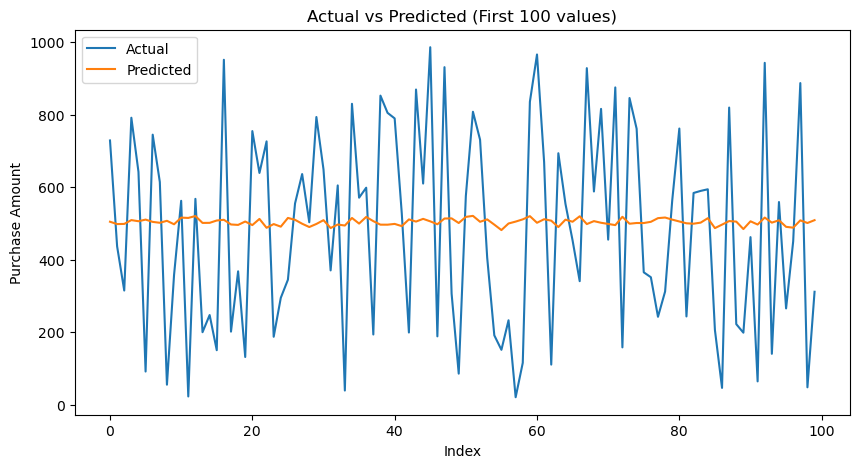

In [ ]:
# 12 : Compare Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted (First 100 values)")
plt.xlabel("Index")
plt.ylabel("Purchase Amount")

plt.show()

In [55]:
# 13 : Model Coefficients
coefficients = pd.DataFrame(model.coef_, columns=["Coefficient"])
coefficients["Feature"] = df.drop("Purchase_Amount", axis=1).columns
coefficients

,Coefficient,Feature
0,0.880075,Quantity
1,0.498033,year
2,-2.634856,month
3,1.012153,day
4,1.003247,Country_Brazil
5,-0.576120,Country_Canada
6,1.637828,Country_France
7,-3.527721,Country_Germany
8,-1.735117,Country_India
9,0.063589,Country_Japan
